# Exercise Pose Estimation — Classical ML Pipeline

## Design
- **Training only:** MediaPipe Heavy runs once to generate 3D joint ground-truth labels
- **CV pipeline (training + inference):** HOG+SVM person detector → CSRT tracker → feature extraction (no deep learning)
- **Features:** Global HOG + 5 body-part HOG patches + optical flow + silhouette mask + limb ratios
- **Models:** Ridge, SVR, Random Forest, XGBoost compared per exercise — best by val MPJPE is saved
- **Inference:** Raw RGB video → CV pipeline → saved model → 3D joints (no MediaPipe, no PyTorch needed)

## How to run
1. Runtime → Change runtime type → T4 GPU (optional, speeds up MediaPipe labelling)
2. Runtime → Run all
3. Upload kaggle.json when Cell 1.0 prompts
4. Check Cell 1.2 output and edit EXERCISE_FOLDER_MAP in Cell 1.3 if needed


## 0 — Setup & Configuration

In [1]:
# -- 0.0 Configuration --
import os

WORK_DIR = '/kaggle/working/ExercisePose'
FEAT_DIR = '/kaggle/working/ExercisePose/feats'
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(FEAT_DIR, exist_ok=True)

EXERCISES = ['squat', 'push_up', 'pull_up']

MAX_VIDEOS_PER_EXERCISE = 20
MAX_FRAMES_PER_VIDEO    = 200
FRAME_STRIDE            = 2      # sample every Nth frame

# HOG settings
HOG_IMG_SIZE      = (128, 64)    # H x W for full-body crop
HOG_ORIENTATIONS  = 9
HOG_PPC           = (8, 8)       # pixels per cell
HOG_CPB           = (2, 2)       # cells per block

# Body-part patch sizes (H x W)
PATCH_HEAD        = (48, 48)
PATCH_TORSO       = (64, 48)
PATCH_ARM         = (64, 32)
PATCH_LEGS        = (64, 48)

# Optical flow
FLOW_RESIZE       = (32, 16)     # downsampled flow map (H x W)

# Joint definitions — H36M 17-joint
JOINT_NAMES = [
    'Hip','RHip','RKnee','RAnkle',
    'LHip','LKnee','LAnkle',
    'Spine','Thorax','Neck','Head',
    'LShoulder','LElbow','LWrist',
    'RShoulder','RElbow','RWrist'
]
EDGES = [
    (0,1),(1,2),(2,3),(0,4),(4,5),(5,6),
    (0,7),(7,8),(8,9),(9,10),
    (8,11),(11,12),(12,13),(8,14),(14,15),(15,16)
]
HIP,RHIP,RKNEE,RANKLE   = 0,1,2,3
LHIP,LKNEE,LANKLE       = 4,5,6
SPINE,THORAX,NECK,HEAD  = 7,8,9,10
LSHOULDER,LELBOW,LWRIST = 11,12,13
RSHOULDER,RELBOW,RWRIST = 14,15,16

RANDOM_STATE = 42

print('Config loaded')
print(f'  Exercises : {EXERCISES}')
print(f'  HOG size  : {HOG_IMG_SIZE}')


Config loaded
  Exercises : ['squat', 'push_up', 'pull_up']
  HOG size  : (128, 64)


In [2]:
# -- 0.1 Install dependencies --
import subprocess, sys
pkgs = ['mediapipe', 'scikit-learn', 'scikit-image',
        'kaggle', 'tqdm', 'scipy', 'xgboost']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Packages ready')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


Packages ready


In [3]:
# -- 0.2 Imports --
import os, cv2, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict, Counter
warnings.filterwarnings('ignore')

from skimage.feature import hog
from skimage.transform import resize as sk_resize

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
import mediapipe as mp

plt.style.use('dark_background')

def bgr2rgb(img): return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
def save_fig(name): plt.savefig(os.path.join(WORK_DIR, name), dpi=100, bbox_inches='tight', facecolor='#111')
print(f'Imports ready')


2026-05-05 10:01:24.272194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777975284.646932      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777975284.761200      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777975285.762847      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777975285.762895      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777975285.762898      57 computation_placer.cc:177] computation placer alr

Imports ready


## 1 — Download Dataset

In [4]:
# -- 1.1 Dataset is mounted --
import zipfile, glob, re, os

DOWNLOAD_DIR = '/kaggle/working/workoutfitness-video'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# Find the actual mounted path
import os
for name in os.listdir('/kaggle/input'):
    print(f'Found: /kaggle/input/{name}')

KAGGLE_INPUT = '/kaggle/input/datasets/hasyimabdillah/workoutfitness-video'

# Copy/extract any zips from input to working (input is read-only)
extracted = False
for fname in os.listdir(KAGGLE_INPUT):
    if fname.endswith('.zip'):
        print(f'Extracting {fname} ...')
        with zipfile.ZipFile(os.path.join(KAGGLE_INPUT, fname)) as zf:
            zf.extractall(DOWNLOAD_DIR)
        print('Extracted'); extracted = True; break

if not extracted:
    DOWNLOAD_DIR = KAGGLE_INPUT
    print('Dataset files found directly (no zip)')

print(f'Dataset ready at: {DOWNLOAD_DIR}')

Found: /kaggle/input/datasets
Dataset files found directly (no zip)
Dataset ready at: /kaggle/input/datasets/hasyimabdillah/workoutfitness-video


In [5]:
# -- 1.2 Scan videos --
def find_videos(root):
    vm = defaultdict(list)
    for ext in ['*.mp4','*.avi','*.mov','*.mkv','*.MOV']:
        for path in glob.glob(os.path.join(root,'**',ext), recursive=True):
            folder = os.path.basename(os.path.dirname(path)).lower()
            folder = re.sub(r'[^a-z0-9_]','_',
                            folder.replace(' ','_').replace('-','_'))
            vm[folder].append(path)
    return vm

raw_map = find_videos(DOWNLOAD_DIR)
print('Folders found:')
for folder, paths in sorted(raw_map.items()):
    print(f"  '{folder}'  ->  {len(paths)} videos")
print(f'Total: {sum(len(v) for v in raw_map.values())} videos')

Folders found:
  'barbell_biceps_curl'  ->  62 videos
  'bench_press'  ->  61 videos
  'chest_fly_machine'  ->  28 videos
  'deadlift'  ->  32 videos
  'decline_bench_press'  ->  12 videos
  'hammer_curl'  ->  19 videos
  'hip_thrust'  ->  18 videos
  'incline_bench_press'  ->  33 videos
  'lat_pulldown'  ->  51 videos
  'lateral_raise'  ->  37 videos
  'leg_extension'  ->  25 videos
  'leg_raises'  ->  21 videos
  'plank'  ->  7 videos
  'pull_up'  ->  26 videos
  'push_up'  ->  56 videos
  'romanian_deadlift'  ->  14 videos
  'russian_twist'  ->  13 videos
  'shoulder_press'  ->  17 videos
  'squat'  ->  29 videos
  't_bar_row'  ->  21 videos
  'tricep_dips'  ->  20 videos
  'tricep_pushdown'  ->  50 videos
Total: 652 videos


In [6]:
# -- 1.3 Map folder names to exercise labels --
EXERCISE_FOLDER_MAP = {
    'squat'   : 'squat',
    'push_up' : 'push_up',   # 'push-up' becomes 'push_up' after normalisation
    'pull_up' : 'pull_up',   # 'pull Up' becomes 'pull_up' after normalisation
}

VIDEO_MAP = {}
for label, folder in EXERCISE_FOLDER_MAP.items():
    vids = raw_map.get(folder, [])
    if not vids:
        vids = [v for k,vs in raw_map.items()
                if any(p in k for p in label.split('_')) for v in vs]
        if vids: print(f'  {label}: fuzzy matched {len(vids)} videos')
    VIDEO_MAP[label] = sorted(vids)[:MAX_VIDEOS_PER_EXERCISE]

print('Videos per exercise (capped):')
for label, vids in VIDEO_MAP.items():
    status = 'OK' if vids else 'NOT FOUND'
    print(f'  {label:<12}: {len(vids):>3} videos  {status}')
print(f'Total: {sum(len(v) for v in VIDEO_MAP.values())} videos')

Videos per exercise (capped):
  squat       :  20 videos  OK
  push_up     :  20 videos  OK
  pull_up     :  20 videos  OK
Total: 60 videos


## 2 — MediaPipe Labelling (training only)
MediaPipe runs **once** here to generate ground-truth 3D joint labels.
It is **not used at inference time**.

In [7]:
# -- 2.0 Setup MediaPipe --
import urllib.request

MODEL_PATH = '/content/pose_landmarker_heavy.task'
if not os.path.exists(MODEL_PATH):
    print('Downloading MediaPipe pose model (~25 MB)...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/'
        'pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task',
        MODEL_PATH)
    print('Downloaded')
else:
    print('Model already present')

BaseOptions        = mp.tasks.BaseOptions
PoseLandmarker     = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOpts = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode  = mp.tasks.vision.RunningMode

mp_options = PoseLandmarkerOpts(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5)

# MediaPipe landmark indices
MP_L_HIP=23; MP_R_HIP=24; MP_L_KNEE=25; MP_R_KNEE=26
MP_L_ANKLE=27; MP_R_ANKLE=28
MP_L_SHOULDER=11; MP_R_SHOULDER=12
MP_L_ELBOW=13; MP_R_ELBOW=14
MP_L_WRIST=15; MP_R_WRIST=16
MP_L_EAR=7; MP_R_EAR=8

def mp_to_h36m(landmarks):
    """Convert MediaPipe 33-point landmarks to H36M 17-joint format."""
    lm = landmarks
    def g(i): return np.array([lm[i].x, lm[i].y, lm[i].z])
    def mid(a, b): return (g(a) + g(b)) / 2
    hip    = mid(MP_L_HIP,      MP_R_HIP)
    thorax = mid(MP_L_SHOULDER, MP_R_SHOULDER)
    spine  = (hip + thorax) / 2
    neck   = (thorax + mid(MP_L_EAR, MP_R_EAR)) / 2
    head   = mid(MP_L_EAR, MP_R_EAR)
    return np.array([
        hip,
        g(MP_R_HIP),   g(MP_R_KNEE),  g(MP_R_ANKLE),
        g(MP_L_HIP),   g(MP_L_KNEE),  g(MP_L_ANKLE),
        spine, thorax, neck, head,
        g(MP_L_SHOULDER), g(MP_L_ELBOW), g(MP_L_WRIST),
        g(MP_R_SHOULDER), g(MP_R_ELBOW), g(MP_R_WRIST),
    ])  # (17, 3)

def normalise_torso(joints_3d):
    """Normalise skeleton so torso length = 1.0. Input: (T,17,3) or (17,3)."""
    single = joints_3d.ndim == 2
    if single: joints_3d = joints_3d[None]
    torso = np.linalg.norm(joints_3d[:, THORAX] - joints_3d[:, HIP], axis=-1)
    torso = np.where(torso == 0, 1.0, torso)[:, None, None]
    out = joints_3d / torso
    return out[0] if single else out

print(f'MediaPipe {mp.__version__} ready')


Downloaded
MediaPipe 0.10.35 ready


In [8]:
# -- 2.1 Label all videos with MediaPipe --
LABELS_CACHE = os.path.join(FEAT_DIR, 'mediapipe_labels.pkl')

def label_video(video_path, max_frames=MAX_FRAMES_PER_VIDEO, stride=FRAME_STRIDE):
    cap = cv2.VideoCapture(video_path)
    joints_list, frame_list, bbox_list = [], [], []
    fi = 0
    with PoseLandmarker.create_from_options(mp_options) as detector:
        while True:
            ret, frame = cap.read()
            if not ret or fi >= max_frames * stride: break
            if fi % stride != 0:
                fi += 1; continue
            rgb = bgr2rgb(frame)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            res = detector.detect(mp_img)
            if res.pose_world_landmarks:
                j3d = mp_to_h36m(res.pose_world_landmarks[0])
                joints_list.append(j3d)
                frame_list.append(fi)
                # Compute bounding box from 2D landmarks for region cropping
                if res.pose_landmarks:
                    H, W = frame.shape[:2]
                    lm2d = res.pose_landmarks[0]
                    xs = [l.x * W for l in lm2d]
                    ys = [l.y * H for l in lm2d]
                    pad = 20
                    x1 = max(0, int(min(xs)) - pad)
                    y1 = max(0, int(min(ys)) - pad)
                    x2 = min(W, int(max(xs)) + pad)
                    y2 = min(H, int(max(ys)) + pad)
                    bbox_list.append((x1, y1, x2, y2))
                else:
                    bbox_list.append(None)
            fi += 1
    cap.release()
    if not joints_list: return None
    j3d_arr = np.array(joints_list)  # (T, 17, 3)
    return {
        'joints_3d'     : j3d_arr,
        'joints_3d_norm': normalise_torso(j3d_arr),
        'frame_indices' : frame_list,
        'bboxes'        : bbox_list,
        'n_frames'      : len(joints_list),
    }

if os.path.exists(LABELS_CACHE):
    print('Loading cached labels...')
    with open(LABELS_CACHE, 'rb') as f: ALL_RECORDS = pickle.load(f)
    print(f'Loaded {len(ALL_RECORDS)} records')
else:
    ALL_RECORDS = []
    for exercise, paths in VIDEO_MAP.items():
        if not paths: print(f'  {exercise}: no videos'); continue
        print(f'\n-- {exercise} ({len(paths)} videos) --')
        for vpath in tqdm(paths, desc=exercise):
            rec = label_video(vpath)
            if rec is None:
                print(f'  skip {os.path.basename(vpath)}'); continue
            rec['video_path'] = vpath
            rec['exercise']   = exercise
            ALL_RECORDS.append(rec)
            print(f"  {os.path.basename(vpath):<40} {rec['n_frames']:>4} frames")
    with open(LABELS_CACHE, 'wb') as f: pickle.dump(ALL_RECORDS, f)
    print(f'Saved {len(ALL_RECORDS)} records')

ex_counts = Counter(r['exercise'] for r in ALL_RECORDS)
print('\nSummary:')
for ex in EXERCISES:
    cnt = ex_counts.get(ex, 0)
    nf  = sum(r['n_frames'] for r in ALL_RECORDS if r['exercise'] == ex)
    print(f"  {'OK' if cnt>0 else 'MISSING'} {ex:<12}: {cnt} videos, {nf:,} frames")



-- squat (20 videos) --


squat:   0%|          | 0/20 [00:00<?, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777975316.357718     171 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777975316.477210     172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777975316.670404     170 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
squat:   5%|▌         | 1/20 [00:21<06:39, 21.02s/it]

  squat_1.MOV                               197 frames


W0000 00:00:1777975337.149708     187 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777975337.273280     187 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
squat:  10%|█         | 2/20 [00:29<04:04, 13.58s/it]

  squat_10.mp4                               88 frames


...

  pull up_25.mp4                             27 frames


W0000 00:00:1777975835.355473     927 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777975835.450468     927 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
pull_up:  95%|█████████▌| 19/20 [02:46<00:05,  5.75s/it]

  pull up_26.mp4                             32 frames


W0000 00:00:1777975839.604409     940 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777975839.670718     940 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
pull_up: 100%|██████████| 20/20 [03:06<00:00,  9.31s/it]

  pull up_3.mp4                             200 frames
Saved 60 records

Summary:
  OK squat       : 20 videos, 2,366 frames
  OK push_up     : 20 videos, 1,312 frames
  OK pull_up     : 20 videos, 1,927 frames


## 3 — Classical CV Feature Extraction

**Person localisation:** HOG+SVM person detector → CSRT tracker (re-detects every 30 frames)

**Feature vector per frame:**
1. Global HOG on full-body crop (128×64) — captures overall body shape and orientation
2. Five body-part HOG patches (head / torso / left-arm / right-arm / legs) — local shape detail
3. Dense optical flow (32×16 magnitude+angle, flattened) — motion signal between frames
4. Silhouette mask HOG (skin-colour + edge thresholding) — body outline without background
5. Geometric limb ratios (14 normalised distances + 8 angles from bounding-box keypoints) — body proportion

During **training** the MediaPipe bounding boxes are used directly (ground truth person location).
During **inference** the HOG+SVM detector + CSRT tracker locates the person.

In [9]:
# -- 3.0 HOG feature utilities --

def compute_hog(img_bgr, target_size):
    """Resize img to target_size (H,W) and compute HOG. Returns 1-D float32 array."""
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim == 3 else img_bgr
    img_resized = cv2.resize(img_gray, (target_size[1], target_size[0]))
    feat = hog(
        img_resized,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PPC,
        cells_per_block=HOG_CPB,
        block_norm='L2-Hys',
        feature_vector=True
    )
    return feat.astype(np.float32)


def extract_optical_flow(prev_gray, curr_gray):
    """Dense Farneback optical flow → flattened (mag, angle) at FLOW_RESIZE. Returns float32."""
    if prev_gray is None:
        return np.zeros(2 * FLOW_RESIZE[0] * FLOW_RESIZE[1], dtype=np.float32)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    mag_ds = cv2.resize(mag, (FLOW_RESIZE[1], FLOW_RESIZE[0])).flatten()
    ang_ds = cv2.resize(ang, (FLOW_RESIZE[1], FLOW_RESIZE[0])).flatten()
    mag_ds = mag_ds / (mag_ds.max() + 1e-6)
    ang_ds = ang_ds / (2 * np.pi)
    return np.concatenate([mag_ds, ang_ds]).astype(np.float32)


def extract_silhouette_hog(img_bgr, target_size=(64, 32)):
    """Skin-colour mask + Canny edges combined into a silhouette, then HOG."""
    img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    # Skin colour range in HSV
    skin_mask = cv2.inRange(img_hsv,
                            np.array([0, 20, 70]),
                            np.array([20, 255, 255]))
    edges    = cv2.Canny(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), 50, 150)
    combined = cv2.bitwise_or(skin_mask, edges)
    combined = cv2.GaussianBlur(combined, (3, 3), 0)
    return compute_hog(combined, target_size)


def safe_crop(img, x1, y1, x2, y2, min_size=16):
    """Crop img with boundary checks; returns None if crop is too small."""
    H, W = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    if (x2 - x1) < min_size or (y2 - y1) < min_size:
        return None
    return img[y1:y2, x1:x2]


def extract_body_part_hogs(img_bgr, x1, y1, x2, y2):
    """
    Divide the bounding box into 5 regions and compute HOG for each:
      head (top 20%) / torso (20-55%) / left-arm / right-arm / legs (55-100%)
    Returns concatenated float32 array.
    """
    bw = x2 - x1
    bh = y2 - y1

    regions = {
        'head'     : (x1,           y1,           x2,           y1 + int(0.22*bh)),
        'torso'    : (x1,           y1 + int(0.22*bh), x2,      y1 + int(0.55*bh)),
        'left_arm' : (x1,           y1 + int(0.22*bh), x1+bw//2, y1 + int(0.70*bh)),
        'right_arm': (x1 + bw//2,   y1 + int(0.22*bh), x2,      y1 + int(0.70*bh)),
        'legs'     : (x1,           y1 + int(0.55*bh), x2,      y2),
    }
    sizes = {
        'head'     : PATCH_HEAD,
        'torso'    : PATCH_TORSO,
        'left_arm' : PATCH_ARM,
        'right_arm': PATCH_ARM,
        'legs'     : PATCH_LEGS,
    }

    feats = []
    for name, (rx1,ry1,rx2,ry2) in regions.items():
        crop = safe_crop(img_bgr, rx1, ry1, rx2, ry2)
        if crop is None:
            # Fallback: zeros with correct dim
            dummy = np.zeros(sizes[name], dtype=np.uint8)
            feats.append(compute_hog(dummy, sizes[name]))
        else:
            feats.append(compute_hog(crop, sizes[name]))
    return np.concatenate(feats)


def extract_geometric_ratios(x1, y1, x2, y2):
    """
    Estimate geometric body proportions purely from the bounding box.
    These act as scale-normalised shape priors.
    Returns 6-dim float32 array.
    """
    bw = x2 - x1 + 1e-6
    bh = y2 - y1 + 1e-6
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    aspect   = bw / bh           # width / height ratio
    rel_cx   = cx / 640.0        # approximate: normalise by typical frame width
    rel_cy   = cy / 480.0
    rel_w    = bw / 640.0
    rel_h    = bh / 480.0
    area     = (bw * bh) / (640.0 * 480.0)
    return np.array([aspect, rel_cx, rel_cy, rel_w, rel_h, area], dtype=np.float32)


# Compute and print feature dimensions
_dummy_img = np.zeros((480, 640, 3), dtype=np.uint8)
_hog_global   = compute_hog(_dummy_img, HOG_IMG_SIZE)
_hog_parts    = extract_body_part_hogs(_dummy_img, 100, 50, 400, 400)
_flow         = extract_optical_flow(None, None)
_sil_hog      = extract_silhouette_hog(_dummy_img)
_geom         = extract_geometric_ratios(100, 50, 400, 400)

DIM_HOG_GLOBAL = len(_hog_global)
DIM_HOG_PARTS  = len(_hog_parts)
DIM_FLOW       = len(_flow)
DIM_SIL        = len(_sil_hog)
DIM_GEOM       = len(_geom)
TOTAL_FEAT_DIM = DIM_HOG_GLOBAL + DIM_HOG_PARTS + DIM_FLOW + DIM_SIL + DIM_GEOM

print('Feature dimensions:')
print(f'  Global HOG (full body)   : {DIM_HOG_GLOBAL}')
print(f'  Body-part HOG (5 patches): {DIM_HOG_PARTS}')
print(f'  Optical flow             : {DIM_FLOW}')
print(f'  Silhouette HOG           : {DIM_SIL}')
print(f'  Geometric ratios         : {DIM_GEOM}')
print(f'  TOTAL                    : {TOTAL_FEAT_DIM}')


Feature dimensions:
  Global HOG (full body)   : 3780
  Body-part HOG (5 patches): 4932
  Optical flow             : 1024
  Silhouette HOG           : 756
  Geometric ratios         : 6
  TOTAL                    : 10498


In [10]:
# -- 3.1 Extract features for all labelled frames (training) --
# During training we use MediaPipe bounding boxes — no detector needed.

FEAT_CACHE = os.path.join(FEAT_DIR, 'classical_features.pkl')

def extract_features_for_record(rec):
    """
    Extract the full feature vector for every labelled frame in a record.
    Uses MediaPipe bounding boxes (available during training).
    Returns list of (feature_vector, joint_target) pairs.
    """
    cap = cv2.VideoCapture(rec['video_path'])
    pairs = []
    prev_gray = None

    for si, fi in enumerate(rec['frame_indices']):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret: continue

        bbox = rec['bboxes'][si]
        if bbox is None: continue
        x1, y1, x2, y2 = bbox

        # Crop to person bounding box
        crop = safe_crop(frame, x1, y1, x2, y2)
        if crop is None: continue

        # Resize full-body crop for global HOG
        crop_resized = cv2.resize(crop, (HOG_IMG_SIZE[1], HOG_IMG_SIZE[0]))
        curr_gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Feature extraction
        hog_global = compute_hog(crop_resized, HOG_IMG_SIZE)
        hog_parts  = extract_body_part_hogs(frame, x1, y1, x2, y2)
        flow_feat  = extract_optical_flow(prev_gray, curr_gray)
        sil_feat   = extract_silhouette_hog(crop_resized)
        geom_feat  = extract_geometric_ratios(x1, y1, x2, y2)

        feat_vec = np.concatenate([hog_global, hog_parts, flow_feat, sil_feat, geom_feat])
        target   = rec['joints_3d_norm'][si].flatten()  # (51,)

        if not np.isnan(feat_vec).any() and not np.isnan(target).any():
            pairs.append((feat_vec, target))

        prev_gray = curr_gray

    cap.release()
    return pairs


if os.path.exists(FEAT_CACHE):
    print('Loading cached features...')
    with open(FEAT_CACHE, 'rb') as f:
        X_all, y_all, labels_all = pickle.load(f)
    print(f'Loaded: X={X_all.shape}, y={y_all.shape}')
else:
    X_parts, y_parts, lbl_parts = [], [], []
    for rec in tqdm(ALL_RECORDS, desc='Feature extraction'):
        pairs = extract_features_for_record(rec)
        if not pairs: continue
        Xv = np.array([p[0] for p in pairs])
        yv = np.array([p[1] for p in pairs])
        X_parts.append(Xv)
        y_parts.append(yv)
        lbl_parts.extend([rec['exercise']] * len(pairs))
        print(f"  {os.path.basename(rec['video_path']):<42} {len(pairs)} frames")

    X_all      = np.vstack(X_parts)
    y_all      = np.vstack(y_parts)
    labels_all = lbl_parts
    with open(FEAT_CACHE, 'wb') as f:
        pickle.dump((X_all, y_all, labels_all), f)
    print(f'Saved feature cache')

print(f'\nDataset:')
print(f'  Samples : {X_all.shape[0]:,}')
print(f'  Features: {X_all.shape[1]:,}')
print(f'  Targets : {y_all.shape[1]} (17 joints × 3)')
print(f'  Classes : {dict(Counter(labels_all))}')


Feature extraction:   2%|▏         | 1/60 [03:23<3:19:58, 203.37s/it]

  squat_1.MOV                                197 frames


Feature extraction:   3%|▎         | 2/60 [03:55<1:39:21, 102.79s/it]

  squat_10.mp4                               88 frames


Feature extraction:   5%|▌         | 3/60 [04:22<1:04:39, 68.07s/it] 

...

Feature extraction:  98%|█████████▊| 59/60 [59:02<00:27, 27.07s/it]

  pull up_26.mp4                             32 frames


Feature extraction: 100%|██████████| 60/60 [1:04:02<00:00, 64.05s/it] 

  pull up_3.mp4                              200 frames


Saved feature cache

Dataset:
  Samples : 5,605
  Features: 10,498
  Targets : 51 (17 joints × 3)
  Classes : {'squat': 2366, 'push_up': 1312, 'pull_up': 1927}


## 4 — Model Training & Selection

For each exercise, four classical ML models are trained and compared on validation MPJPE.
The best model per exercise is saved for inference.

**Pipeline:** StandardScaler → PCA (reduce to 150 components) → Regressor

**Models compared:**
- Ridge regression (fast baseline)
- SVR (per output, via MultiOutputRegressor)
- Random Forest
- XGBoost

In [11]:
# -- 4.0 Metrics + train/val/test split --

def mpjpe(y_pred, y_true):
    """Mean per-joint position error (lower is better)."""
    return float(np.mean(
        np.linalg.norm(
            y_pred.reshape(-1, 17, 3) - y_true.reshape(-1, 17, 3),
            axis=-1)))

def pck(y_pred, y_true, threshold=0.15):
    """Percentage of correct keypoints within threshold (higher is better)."""
    d = np.linalg.norm(
        y_pred.reshape(-1, 17, 3) - y_true.reshape(-1, 17, 3), axis=-1)
    return float(100 * (d < threshold).mean())

def mpjpe_per_joint(y_pred, y_true):
    return np.mean(
        np.linalg.norm(
            y_pred.reshape(-1, 17, 3) - y_true.reshape(-1, 17, 3),
            axis=-1), axis=0)


# Stratified split: 70% train / 15% val / 15% test
X_tv, X_test, y_tv, y_test, lbl_tv, lbl_test = train_test_split(
    X_all, y_all, labels_all, test_size=0.15,
    random_state=RANDOM_STATE, stratify=labels_all)

X_train, X_val, y_train, y_val, lbl_train, lbl_val = train_test_split(
    X_tv, y_tv, lbl_tv, test_size=0.176,   # 0.176 of 0.85 ≈ 0.15 of total
    random_state=RANDOM_STATE, stratify=lbl_tv)

print('Split:')
print(f'  Train : {X_train.shape[0]:,}  {dict(Counter(lbl_train))}')
print(f'  Val   : {X_val.shape[0]:,}')
print(f'  Test  : {X_test.shape[0]:,}')


Split:
  Train : 3,925  {'squat': 1657, 'push_up': 919, 'pull_up': 1349}
  Val   : 839
  Test  : 841


In [12]:
# -- 4.1 Define model candidates --

N_PCA = 150   # PCA components — balances compression vs. information retention

def make_pipeline(regressor):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=N_PCA, whiten=True, random_state=RANDOM_STATE)),
        ('reg',    regressor),
    ])

MODEL_CANDIDATES = {
    'Ridge': make_pipeline(
        MultiOutputRegressor(
            Ridge(alpha=1.0),
            n_jobs=-1)
    ),
    'SVR': make_pipeline(
        MultiOutputRegressor(
            SVR(kernel='rbf', C=10.0, epsilon=0.01),
            n_jobs=-1)
    ),
    'RandomForest': make_pipeline(
        MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=200, max_depth=12,
                min_samples_leaf=3, n_jobs=-1,
                random_state=RANDOM_STATE),
            n_jobs=1)
    ),
    'XGBoost': make_pipeline(
        MultiOutputRegressor(
            xgb.XGBRegressor(
                n_estimators=300, max_depth=6,
                learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, reg_alpha=0.1,
                n_jobs=-1, random_state=RANDOM_STATE,
                tree_method='hist', verbosity=0),
            n_jobs=1)
    ),
}

print('Model candidates:')
for name in MODEL_CANDIDATES:
    print(f'  {name}')


Model candidates:
  Ridge
  SVR
  RandomForest
  XGBoost


In [13]:
# -- 4.2 Train & compare all models per exercise --

MODELS_SAVE_PATH = os.path.join(WORK_DIR, 'best_models.pkl')
RESULTS = {}   # {exercise: {model_name: {val_mpjpe, val_pck}}}
BEST_MODELS = {}   # {exercise: trained_pipeline}

if os.path.exists(MODELS_SAVE_PATH):
    print('Loading saved models...')
    with open(MODELS_SAVE_PATH, 'rb') as f:
        BEST_MODELS, RESULTS = pickle.load(f)
    print('Loaded')
else:
    for ex in EXERCISES:
        mask_tr  = np.array(lbl_train) == ex
        mask_val = np.array(lbl_val)   == ex

        if mask_tr.sum() < 30:
            print(f'\n{ex}: too few samples ({mask_tr.sum()}), skipping')
            continue

        X_tr = X_train[mask_tr]; y_tr = y_train[mask_tr]
        X_vl = X_val[mask_val];  y_vl = y_val[mask_val]

        print(f'\n=== {ex} ({mask_tr.sum()} train samples) ===')
        RESULTS[ex] = {}
        best_mpjpe  = np.inf
        best_name   = None
        best_model  = None

        for model_name, pipeline in MODEL_CANDIDATES.items():
            print(f'  Training {model_name}...', end=' ', flush=True)
            # Clone the pipeline so candidates stay reusable
            from sklearn.base import clone
            pipe = clone(pipeline)
            pipe.fit(X_tr, y_tr)
            y_pred_val = pipe.predict(X_vl)
            vm = mpjpe(y_pred_val, y_vl)
            vp = pck(y_pred_val,  y_vl)
            RESULTS[ex][model_name] = {'val_mpjpe': vm, 'val_pck': vp}
            marker = '  ← BEST' if vm < best_mpjpe else ''
            print(f'val MPJPE={vm:.4f}  PCK={vp:.1f}%{marker}')
            if vm < best_mpjpe:
                best_mpjpe = vm
                best_name  = model_name
                best_model = pipe

        BEST_MODELS[ex] = best_model
        print(f'  >> Best for {ex}: {best_name} (MPJPE={best_mpjpe:.4f})')

    with open(MODELS_SAVE_PATH, 'wb') as f:
        pickle.dump((BEST_MODELS, RESULTS), f)
    print('\nAll models saved')



=== squat (1657 train samples) ===
  Training Ridge... val MPJPE=0.1440  PCK=68.8%  ← BEST
  Training SVR... val MPJPE=0.0981  PCK=83.7%  ← BEST
  Training RandomForest... val MPJPE=0.1217  PCK=79.2%
  Training XGBoost... val MPJPE=0.1091  PCK=81.3%
  >> Best for squat: SVR (MPJPE=0.0981)

=== push_up (919 train samples) ===
  Training Ridge... val MPJPE=0.1158  PCK=77.6%  ← BEST
  Training SVR... val MPJPE=0.1302  PCK=70.4%
  Training RandomForest... val MPJPE=0.1024  PCK=82.7%  ← BEST
  Training XGBoost... val MPJPE=0.0897  PCK=84.5%  ← BEST
  >> Best for push_up: XGBoost (MPJPE=0.0897)

=== pull_up (1349 train samples) ===
  Training Ridge... val MPJPE=0.2015  PCK=57.5%  ← BEST
  Training SVR... val MPJPE=0.1665  PCK=70.0%  ← BEST
  Training RandomForest... val MPJPE=0.1820  PCK=69.2%
  Training XGBoost... val MPJPE=0.1594  PCK=74.6%  ← BEST
  >> Best for pull_up: XGBoost (MPJPE=0.1594)

All models saved


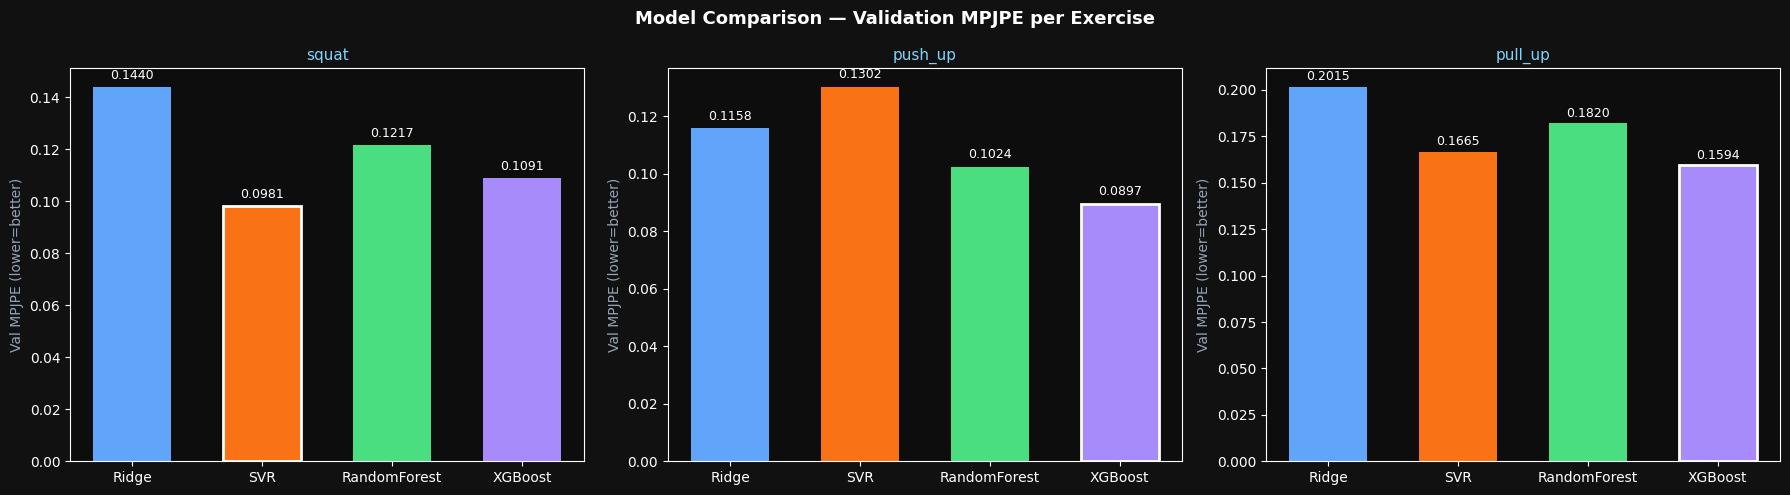

Saved model_comparison.png


In [14]:
# -- 4.3 Visualise model comparison --

model_names = list(list(RESULTS.values())[0].keys())
n_ex = len(RESULTS)

fig, axes = plt.subplots(1, n_ex, figsize=(6*n_ex, 5), facecolor='#111')
fig.suptitle('Model Comparison — Validation MPJPE per Exercise',
             color='white', fontsize=13, fontweight='bold')
if n_ex == 1: axes = [axes]

colors = ['#60a5fa', '#f97316', '#4ade80', '#a78bfa']
for ax, (ex, res) in zip(axes, RESULTS.items()):
    mpjpes = [res[m]['val_mpjpe'] for m in model_names]
    bars = ax.bar(model_names, mpjpes,
                  color=[colors[i] for i in range(len(model_names))], width=0.6)
    best_idx = int(np.argmin(mpjpes))
    bars[best_idx].set_edgecolor('white')
    bars[best_idx].set_linewidth(2)
    for bar, val in zip(bars, mpjpes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=9)
    ax.set_title(ex, color='#7dd3fc', fontsize=11)
    ax.set_ylabel('Val MPJPE (lower=better)', color='#94a3b8')
    ax.set_facecolor('#0d0d0d')
    ax.tick_params(colors='white')

plt.tight_layout()
save_fig('model_comparison.png')
plt.show()
print('Saved model_comparison.png')


Test set evaluation (best model per exercise):
Exercise     Model          MPJPE      PCK@0.15
--------------------------------------------------
squat        SVR            0.0955     84.1%
push_up      XGBoost        0.1026     83.1%
pull_up      XGBoost        0.1573     74.0%
--------------------------------------------------
OVERALL                     0.1184     80.4%


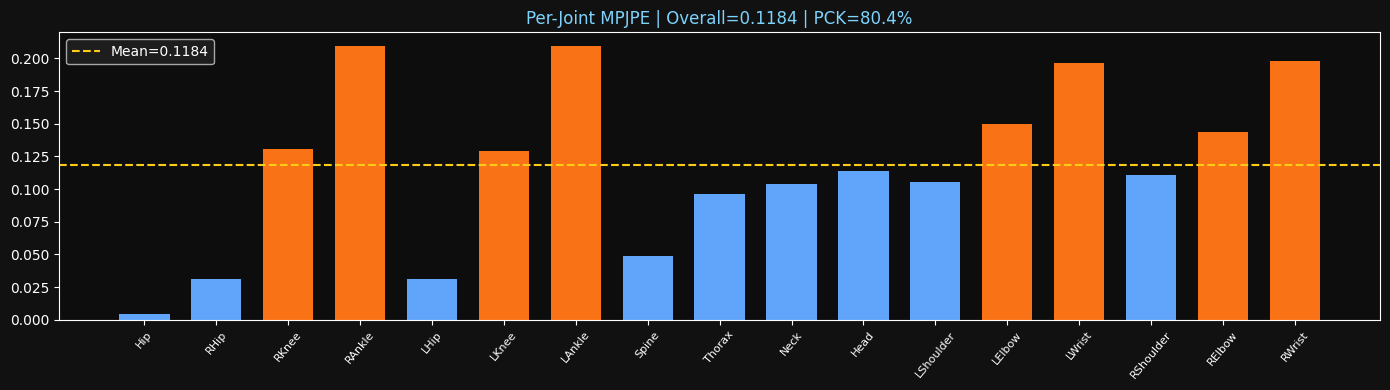

In [15]:
# -- 4.4 Evaluate best models on test set --

print('Test set evaluation (best model per exercise):')
print(f'{"Exercise":<12} {"Model":<14} {"MPJPE":<10} {"PCK@0.15"}')
print('-' * 50)

all_pred = np.zeros_like(y_test)
for i, lbl in enumerate(lbl_test):
    model = BEST_MODELS.get(lbl)
    if model is None: continue
    all_pred[i] = model.predict(X_test[i:i+1])[0]

for ex in EXERCISES:
    mask = np.array(lbl_test) == ex
    if mask.sum() == 0: continue
    best_name = min(RESULTS[ex], key=lambda m: RESULTS[ex][m]['val_mpjpe'])
    em = mpjpe(all_pred[mask], y_test[mask])
    ep = pck(all_pred[mask],  y_test[mask])
    print(f'{ex:<12} {best_name:<14} {em:<10.4f} {ep:.1f}%')

overall_m = mpjpe(all_pred, y_test)
overall_p = pck(all_pred,  y_test)
print('-' * 50)
print(f'{"OVERALL":<12} {"":<14} {overall_m:<10.4f} {overall_p:.1f}%')

# Per-joint error bar chart
pj = mpjpe_per_joint(all_pred, y_test)
fig, ax = plt.subplots(figsize=(14, 4), facecolor='#111')
bar_colors = ['#60a5fa' if e < pj.mean() else '#f97316' for e in pj]
ax.bar(JOINT_NAMES, pj, color=bar_colors, width=0.7)
ax.axhline(pj.mean(), color='#facc15', lw=1.5, ls='--',
           label=f'Mean={pj.mean():.4f}')
ax.set_title(f'Per-Joint MPJPE | Overall={overall_m:.4f} | PCK={overall_p:.1f}%',
             color='#7dd3fc')
ax.tick_params(axis='x', rotation=50, labelsize=8, colors='white')
ax.tick_params(axis='y', colors='white')
ax.set_facecolor('#0d0d0d')
ax.legend(facecolor='#222', labelcolor='white')
plt.tight_layout()
save_fig('per_joint_error.png')
plt.show()


## 5 — Standalone Inference Pipeline

**No MediaPipe. No deep learning.**

Person localisation: HOG+SVM detector → CSRT tracker (re-detects every 30 frames).
Features extracted identically to training.
Best saved model predicts 3D joints.
Joints reprojected onto the frame for visualisation.

In [16]:
# -- 5.0 HOG+SVM person detector + CSRT tracker --

# OpenCV's built-in HOG person detector (pre-trained on pedestrian dataset)
HOG_DETECTOR = cv2.HOGDescriptor()
HOG_DETECTOR.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())


def detect_person(frame, scale=1.05, win_stride=(8,8), padding=(16,16)):
    """
    Run HOG+SVM person detector on a frame.
    Returns the largest detected bounding box (x1,y1,x2,y2) or None.
    """
    rects, weights = HOG_DETECTOR.detectMultiScale(
        frame, winStride=win_stride,
        padding=padding, scale=scale)
    if len(rects) == 0:
        return None
    # Pick the detection with highest weight
    best = rects[np.argmax(weights)]
    x, y, w, h = best
    return (x, y, x+w, y+h)


def init_tracker(frame, bbox_x1y1x2y2):
    """Initialise CSRT tracker from a bounding box."""
    tracker = cv2.TrackerCSRT_create()
    x1, y1, x2, y2 = bbox_x1y1x2y2
    tracker.init(frame, (x1, y1, x2-x1, y2-y1))
    return tracker


def update_tracker(tracker, frame):
    """Update CSRT tracker. Returns (x1,y1,x2,y2) or None on failure."""
    ok, box = tracker.update(frame)
    if not ok: return None
    x, y, w, h = [int(v) for v in box]
    return (x, y, x+w, y+h)


print('HOG+SVM detector ready')
print('CSRT tracker ready')


HOG+SVM detector ready
CSRT tracker ready


In [17]:
# -- 5.1 Full inference function (no MediaPipe) --

REDETECT_EVERY = 30   # re-run HOG+SVM detector every N frames to correct drift

def predict_video(video_path, exercise, visualise=True):
    """
    Run the full classical ML inference pipeline on a video.

    Args:
        video_path : path to input video
        exercise   : 'squat' | 'push_up' | 'pull_up'
        visualise  : whether to produce an annotated output video

    Returns dict with:
        joints_3d_norm  : (T, 17, 3) predicted joints in torso-normalised space
        bboxes          : (T,) bounding boxes used
        frame_indices   : list of frame numbers processed
    """
    model = BEST_MODELS.get(exercise)
    if model is None:
        print(f'No model for {exercise}'); return None

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print('Cannot open video'); return None

    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25

    out_path = None
    if visualise:
        out_path = os.path.join(WORK_DIR,
                   f'inference_{exercise}_{os.path.basename(video_path)}')
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H))

    tracker    = None
    prev_gray  = None
    fi         = 0
    joints_out = []
    bboxes_out = []
    frame_ids  = []

    while True:
        ret, frame = cap.read()
        if not ret: break

        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bbox = None

        # Re-detect every REDETECT_EVERY frames or if tracker lost
        if fi % REDETECT_EVERY == 0 or tracker is None:
            detected = detect_person(frame)
            if detected is not None:
                bbox    = detected
                tracker = init_tracker(frame, bbox)
            elif tracker is not None:
                bbox = update_tracker(tracker, frame)
        else:
            bbox = update_tracker(tracker, frame)
            if bbox is None:
                # Tracker failed — try re-detecting
                detected = detect_person(frame)
                if detected is not None:
                    bbox    = detected
                    tracker = init_tracker(frame, bbox)

        if bbox is not None:
            x1, y1, x2, y2 = bbox
            crop = safe_crop(frame, x1, y1, x2, y2)

            if crop is not None:
                crop_resized = cv2.resize(crop, (HOG_IMG_SIZE[1], HOG_IMG_SIZE[0]))

                hog_global = compute_hog(crop_resized, HOG_IMG_SIZE)
                hog_parts  = extract_body_part_hogs(frame, x1, y1, x2, y2)
                flow_feat  = extract_optical_flow(prev_gray, curr_gray)
                sil_feat   = extract_silhouette_hog(crop_resized)
                geom_feat  = extract_geometric_ratios(x1, y1, x2, y2)

                feat_vec = np.concatenate(
                    [hog_global, hog_parts, flow_feat, sil_feat, geom_feat]
                ).reshape(1, -1)

                joints_norm = model.predict(feat_vec)[0].reshape(17, 3)
                joints_out.append(joints_norm)
                bboxes_out.append(bbox)
                frame_ids.append(fi)

                if visualise:
                    vis = draw_results(frame.copy(), joints_norm, bbox)
                    writer.write(vis)
            else:
                if visualise: writer.write(frame)
        else:
            if visualise: writer.write(frame)

        prev_gray = curr_gray
        fi += 1

    cap.release()
    if visualise:
        writer.release()
        print(f'Output video saved: {out_path}')

    print(f'Processed {fi} frames, predicted on {len(joints_out)}')
    return {
        'joints_3d_norm': np.array(joints_out),
        'bboxes'        : bboxes_out,
        'frame_indices' : frame_ids,
        'exercise'      : exercise,
    }


In [18]:
# -- 5.2 Skeleton overlay drawing --

def draw_results(frame, joints_17_norm, bbox):
    """
    Draw predicted skeleton + bounding box on frame.
    joints_17_norm : (17,3) in torso-normalised space
    bbox           : (x1,y1,x2,y2)
    """
    x1, y1, x2, y2 = bbox
    bw = x2 - x1
    bh = y2 - y1
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    # Scale factor: map torso-normalised coords into pixel space
    # Torso ≈ 40% of body height in the bounding box
    scale = bh * 0.35

    # Project joints: x maps to horizontal centre, y maps downward from top
    px = (cx + joints_17_norm[:, 0] * scale).astype(int)
    py = (cy + joints_17_norm[:, 1] * scale).astype(int)

    # Draw skeleton edges
    for i, j in EDGES:
        if (0 < px[i] < frame.shape[1] and 0 < py[i] < frame.shape[0] and
            0 < px[j] < frame.shape[1] and 0 < py[j] < frame.shape[0]):
            cv2.line(frame, (px[i], py[i]), (px[j], py[j]), (0, 220, 90), 2)

    # Draw joints
    for k in range(17):
        if 0 < px[k] < frame.shape[1] and 0 < py[k] < frame.shape[0]:
            cv2.circle(frame, (px[k], py[k]), 4, (255, 100, 0), -1)

    # Draw bounding box
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 180, 255), 1)
    return frame


print('Draw function ready')


Draw function ready


In [19]:
# -- 5.3 Run inference on a test video --

test_video, test_exercise = None, None
for label, vids in VIDEO_MAP.items():
    if vids and label in BEST_MODELS:
        test_video    = vids[-1]   # use last video (held out from visual inspection)
        test_exercise = label
        break

if test_video:
    print(f'Running inference: {os.path.basename(test_video)}  [{test_exercise}]')
    PRED = predict_video(test_video, test_exercise, visualise=True)
else:
    print('No test video available')
    PRED = None


Running inference: squat_27.mp4  [squat]
Output video saved: /kaggle/working/ExercisePose/inference_squat_squat_27.mp4
Processed 647 frames, predicted on 647


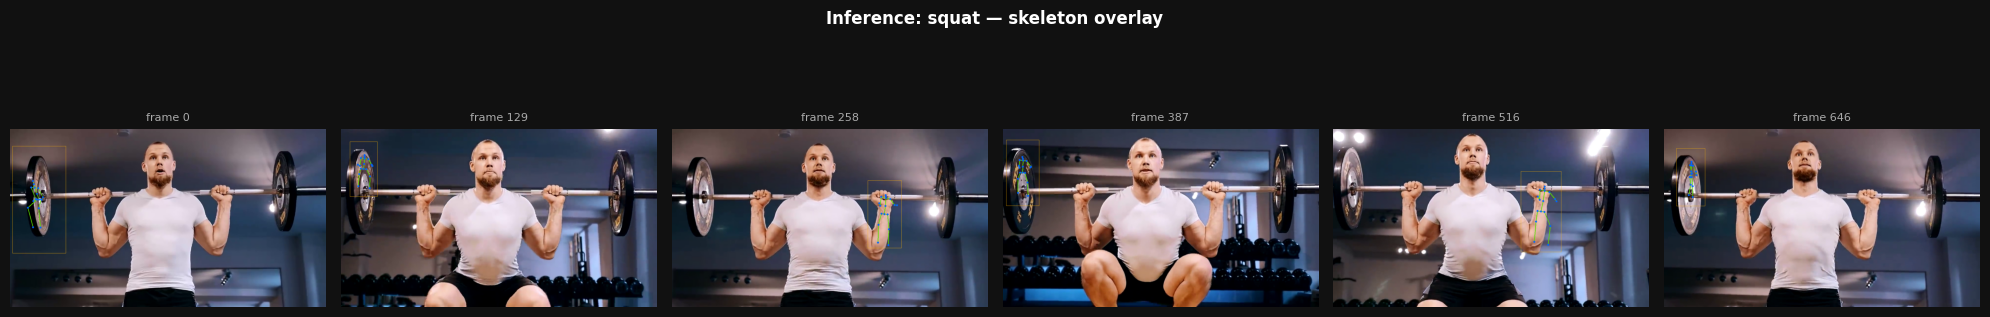

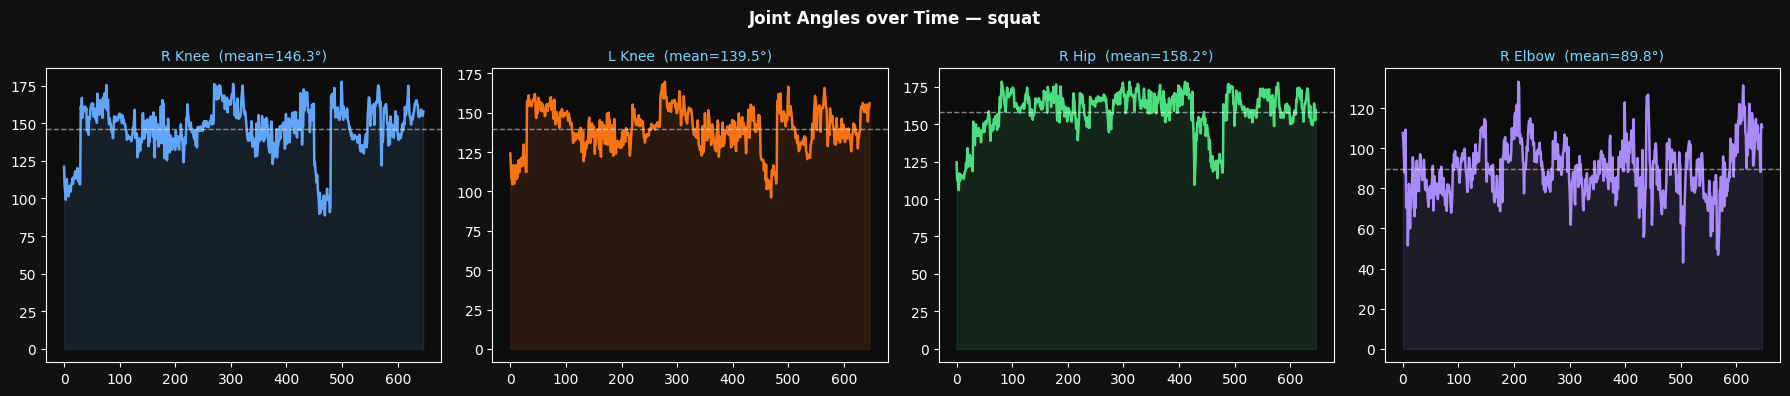

Saved inference_strip.png and inference_angles.png


In [20]:
# -- 5.4 Visualise inference results: frame strip + joint angle plot --

def joint_angle_seq(j_seq, a, b, c):
    va  = j_seq[:, a] - j_seq[:, b]
    vc  = j_seq[:, c] - j_seq[:, b]
    cos = np.einsum('ti,ti->t', va, vc) / (
          np.linalg.norm(va, axis=1) * np.linalg.norm(vc, axis=1) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))


if PRED is not None and len(PRED['joints_3d_norm']) > 0:
    j = PRED['joints_3d_norm']

    # Frame strip (6 evenly spaced frames)
    cap = cv2.VideoCapture(test_video)
    sample_idx = np.linspace(0, len(PRED['frame_indices'])-1, 6, dtype=int)
    fig, axes  = plt.subplots(1, 6, figsize=(20, 4), facecolor='#111')
    fig.suptitle(f'Inference: {test_exercise} — skeleton overlay',
                 color='white', fontsize=12, fontweight='bold')

    for col, idx in enumerate(sample_idx):
        cap.set(cv2.CAP_PROP_POS_FRAMES, PRED['frame_indices'][idx])
        ret, frame = cap.read()
        if not ret: continue
        vis = draw_results(frame, j[idx], PRED['bboxes'][idx])
        axes[col].imshow(bgr2rgb(vis))
        axes[col].set_title(f'frame {PRED["frame_indices"][idx]}',
                            color='#aaa', fontsize=8)
        axes[col].axis('off')
    cap.release()
    plt.tight_layout()
    save_fig('inference_strip.png')
    plt.show()

    # Joint angle plot
    angles = {
        'R Knee' : joint_angle_seq(j, RHIP,      RKNEE,  RANKLE),
        'L Knee' : joint_angle_seq(j, LHIP,      LKNEE,  LANKLE),
        'R Hip'  : joint_angle_seq(j, THORAX,    RHIP,   RKNEE),
        'R Elbow': joint_angle_seq(j, RSHOULDER, RELBOW, RWRIST),
    }
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), facecolor='#111')
    fig.suptitle(f'Joint Angles over Time — {test_exercise}',
                 color='white', fontsize=12, fontweight='bold')
    cols = ['#60a5fa', '#f97316', '#4ade80', '#a78bfa']
    for ax, (name, ang), color in zip(axes, angles.items(), cols):
        ax.plot(ang, color=color, lw=1.8)
        ax.fill_between(range(len(ang)), ang, alpha=0.12, color=color)
        ax.axhline(ang.mean(), color='white', lw=1, ls='--', alpha=0.5)
        ax.set_title(f'{name}  (mean={ang.mean():.1f}°)',
                     color='#7dd3fc', fontsize=10)
        ax.set_facecolor('#0d0d0d')
        ax.tick_params(colors='white')
    plt.tight_layout()
    save_fig('inference_angles.png')
    plt.show()
    print(f'Saved inference_strip.png and inference_angles.png')


## 6 — Export: Standalone Inference Module

In [21]:
# -- 6.0 Save self-contained inference module --
# This .py file has ZERO deep learning dependencies.
# Load best_models.pkl and run predict_frame() on any BGR frame.

INFERENCE_MODULE = os.path.join(WORK_DIR, 'pose_inference.py')

module_code = '''
"""
pose_inference.py — Standalone classical ML pose estimator.
Dependencies: opencv-python, scikit-image, numpy, scipy, xgboost, scikit-learn
No MediaPipe. No PyTorch. No deep learning.

Usage:
    from pose_inference import PoseInference
    pi = PoseInference("best_models.pkl", exercise="squat")
    joints = pi.predict_frame(bgr_frame)   # returns (17,3) numpy array or None
"""
import cv2
import pickle
import numpy as np
from skimage.feature import hog

# ── Constants (must match training) ─────────────────────────────────────────
HOG_IMG_SIZE     = (128, 64)
HOG_ORIENTATIONS = 9
HOG_PPC          = (8, 8)
HOG_CPB          = (2, 2)
FLOW_RESIZE      = (32, 16)
PATCH_HEAD       = (48, 48)
PATCH_TORSO      = (64, 48)
PATCH_ARM        = (64, 32)
PATCH_LEGS       = (64, 48)
REDETECT_EVERY   = 30

EDGES = [
    (0,1),(1,2),(2,3),(0,4),(4,5),(5,6),
    (0,7),(7,8),(8,9),(9,10),
    (8,11),(11,12),(12,13),(8,14),(14,15),(15,16)
]

# ── Feature extraction ───────────────────────────────────────────────────────
def _compute_hog(img_bgr, target_size):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim==3 else img_bgr
    resized = cv2.resize(gray, (target_size[1], target_size[0]))
    return hog(resized, orientations=HOG_ORIENTATIONS,
               pixels_per_cell=HOG_PPC, cells_per_block=HOG_CPB,
               block_norm="L2-Hys", feature_vector=True).astype(np.float32)

def _safe_crop(img, x1, y1, x2, y2, min_size=16):
    H, W = img.shape[:2]
    x1,y1 = max(0,x1), max(0,y1)
    x2,y2 = min(W,x2), min(H,y2)
    if (x2-x1)<min_size or (y2-y1)<min_size: return None
    return img[y1:y2, x1:x2]

def _optical_flow(prev_gray, curr_gray):
    if prev_gray is None:
        return np.zeros(2*FLOW_RESIZE[0]*FLOW_RESIZE[1], dtype=np.float32)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    md = cv2.resize(mag,(FLOW_RESIZE[1],FLOW_RESIZE[0])).flatten()
    ad = cv2.resize(ang,(FLOW_RESIZE[1],FLOW_RESIZE[0])).flatten()
    return np.concatenate([md/(md.max()+1e-6), ad/(2*np.pi)]).astype(np.float32)

def _silhouette_hog(img_bgr, target_size=(64,32)):
    hsv   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    skin  = cv2.inRange(hsv, np.array([0,20,70]), np.array([20,255,255]))
    edges = cv2.Canny(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), 50, 150)
    comb  = cv2.GaussianBlur(cv2.bitwise_or(skin, edges), (3,3), 0)
    return _compute_hog(comb, target_size)

def _body_part_hogs(img_bgr, x1, y1, x2, y2):
    bw, bh = x2-x1, y2-y1
    regions = {
        "head"     :((x1,          y1,           x2,           y1+int(.22*bh)), PATCH_HEAD),
        "torso"    :((x1,          y1+int(.22*bh),x2,          y1+int(.55*bh)), PATCH_TORSO),
        "left_arm" :((x1,          y1+int(.22*bh),x1+bw//2,    y1+int(.70*bh)), PATCH_ARM),
        "right_arm":((x1+bw//2,    y1+int(.22*bh),x2,          y1+int(.70*bh)), PATCH_ARM),
        "legs"     :((x1,          y1+int(.55*bh),x2,          y2),            PATCH_LEGS),
    }
    feats=[]
    for name,((rx1,ry1,rx2,ry2),sz) in regions.items():
        crop = _safe_crop(img_bgr,rx1,ry1,rx2,ry2)
        feats.append(_compute_hog(crop if crop is not None else np.zeros((*sz,3),dtype=np.uint8), sz))
    return np.concatenate(feats)

def _geom(x1,y1,x2,y2):
    bw,bh=x2-x1+1e-6,y2-y1+1e-6
    return np.array([bw/bh,(x1+x2)/2/640,(y1+y2)/2/480,
                     bw/640,bh/480,bw*bh/(640*480)], dtype=np.float32)

def _build_feature(frame, x1, y1, x2, y2, prev_gray, curr_gray):
    crop = _safe_crop(frame, x1, y1, x2, y2)
    if crop is None: return None
    cr = cv2.resize(crop, (HOG_IMG_SIZE[1], HOG_IMG_SIZE[0]))
    return np.concatenate([
        _compute_hog(cr, HOG_IMG_SIZE),
        _body_part_hogs(frame, x1, y1, x2, y2),
        _optical_flow(prev_gray, curr_gray),
        _silhouette_hog(cr),
        _geom(x1, y1, x2, y2),
    ]).reshape(1, -1)

# ── Drawing ──────────────────────────────────────────────────────────────────
def draw_skeleton(frame, joints_norm, bbox):
    x1,y1,x2,y2 = bbox
    scale = (y2-y1)*0.35
    cx,cy = (x1+x2)/2, (y1+y2)/2
    px = (cx + joints_norm[:,0]*scale).astype(int)
    py = (cy + joints_norm[:,1]*scale).astype(int)
    H,W = frame.shape[:2]
    for i,j in EDGES:
        if all(0<v<dim for v,dim in [(px[i],W),(py[i],H),(px[j],W),(py[j],H)]):
            cv2.line(frame,(px[i],py[i]),(px[j],py[j]),(0,220,90),2)
    for k in range(17):
        if 0<px[k]<W and 0<py[k]<H:
            cv2.circle(frame,(px[k],py[k]),4,(255,100,0),-1)
    cv2.rectangle(frame,(x1,y1),(x2,y2),(0,180,255),1)
    return frame

# ── Main class ───────────────────────────────────────────────────────────────
class PoseInference:
    def __init__(self, models_pkl_path, exercise):
        with open(models_pkl_path, "rb") as f:
            best_models, _ = pickle.load(f)
        self.model    = best_models[exercise]
        self.exercise = exercise
        self.detector = cv2.HOGDescriptor()
        self.detector.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
        self.tracker   = None
        self.prev_gray = None
        self.frame_idx = 0

    def _detect(self, frame):
        rects, weights = self.detector.detectMultiScale(
            frame, winStride=(8,8), padding=(16,16), scale=1.05)
        if len(rects)==0: return None
        x,y,w,h = rects[np.argmax(weights)]
        return (x,y,x+w,y+h)

    def predict_frame(self, bgr_frame):
        """
        Process one BGR frame. Returns (17,3) joints in torso-norm space, or None.
        Call sequentially — uses optical flow between frames.
        """
        curr_gray = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2GRAY)
        bbox = None

        if self.frame_idx % REDETECT_EVERY == 0 or self.tracker is None:
            det = self._detect(bgr_frame)
            if det:
                bbox = det
                self.tracker = cv2.TrackerCSRT_create()
                x1,y1,x2,y2 = det
                self.tracker.init(bgr_frame,(x1,y1,x2-x1,y2-y1))
        else:
            ok, box = self.tracker.update(bgr_frame) if self.tracker else (False,None)
            if ok:
                x,y,w,h = [int(v) for v in box]
                bbox = (x,y,x+w,y+h)
            else:
                det = self._detect(bgr_frame)
                if det:
                    bbox = det
                    self.tracker = cv2.TrackerCSRT_create()
                    x1,y1,x2,y2 = det
                    self.tracker.init(bgr_frame,(x1,y1,x2-x1,y2-y1))

        joints = None
        if bbox:
            x1,y1,x2,y2 = bbox
            fv = _build_feature(bgr_frame, x1, y1, x2, y2, self.prev_gray, curr_gray)
            if fv is not None:
                joints = self.model.predict(fv)[0].reshape(17,3)

        self.prev_gray = curr_gray
        self.frame_idx += 1
        return joints, bbox

    def run_video(self, video_path, out_path=None):
        """Process a full video. Optionally write annotated output."""
        cap = cv2.VideoCapture(video_path)
        W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25
        writer = None
        if out_path:
            writer = cv2.VideoWriter(out_path,
                         cv2.VideoWriter_fourcc(*"mp4v"), fps, (W,H))
        results = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            joints, bbox = self.predict_frame(frame)
            results.append((joints, bbox))
            if writer:
                if joints is not None and bbox is not None:
                    frame = draw_skeleton(frame, joints, bbox)
                writer.write(frame)
        cap.release()
        if writer: writer.release()
        return results
'''

with open(INFERENCE_MODULE, 'w') as f:
    f.write(module_code.strip())

print(f'Saved: {INFERENCE_MODULE}')
print()
print('To use in any Python script:')
print('  from pose_inference import PoseInference')
print('  pi = PoseInference("best_models.pkl", exercise="squat")')
print('  joints, bbox = pi.predict_frame(bgr_frame)  # (17,3) or None')
print('  results = pi.run_video("myvideo.mp4", out_path="out.mp4")')


Saved: /kaggle/working/ExercisePose/pose_inference.py

To use in any Python script:
  from pose_inference import PoseInference
  pi = PoseInference("best_models.pkl", exercise="squat")
  joints, bbox = pi.predict_frame(bgr_frame)  # (17,3) or None
  results = pi.run_video("myvideo.mp4", out_path="out.mp4")


In [22]:

# -- Final summary --
print('=' * 60)
print('EXERCISE POSE PIPELINE — CLASSICAL ML')
print('=' * 60)
print(f'  Exercises      : {list(VIDEO_MAP.keys())}')
print(f'  Total videos   : {sum(len(v) for v in VIDEO_MAP.values())}')
print(f'  Total samples  : {X_all.shape[0]:,}')
print(f'  Feature dim    : {X_all.shape[1]:,}')
print()
print('  Feature breakdown:')
print(f'    Global HOG    : {DIM_HOG_GLOBAL}')
print(f'    Body-part HOG : {DIM_HOG_PARTS}')
print(f'    Optical flow  : {DIM_FLOW}')
print(f'    Silhouette HOG: {DIM_SIL}')
print(f'    Geom ratios   : {DIM_GEOM}')
print()
print('  Best models selected:')
for ex in EXERCISES:
    if ex not in RESULTS: continue
    best = min(RESULTS[ex], key=lambda m: RESULTS[ex][m]['val_mpjpe'])
    vm   = RESULTS[ex][best]['val_mpjpe']
    vp   = RESULTS[ex][best]['val_pck']
    print(f'    {ex:<12}: {best:<14} val MPJPE={vm:.4f}  PCK={vp:.1f}%')
print()
print('  Output files:')
print(f'    best_models.pkl     — trained models')
print(f'    pose_inference.py   — standalone inference module')
print(f'    model_comparison.png')
print(f'    per_joint_error.png')
print(f'    inference_strip.png')
print(f'    inference_angles.png')


EXERCISE POSE PIPELINE — CLASSICAL ML
  Exercises      : ['squat', 'push_up', 'pull_up']
  Total videos   : 60
  Total samples  : 5,605
  Feature dim    : 10,498

  Feature breakdown:
    Global HOG    : 3780
    Body-part HOG : 4932
    Optical flow  : 1024
    Silhouette HOG: 756
    Geom ratios   : 6

  Best models selected:
    squat       : SVR            val MPJPE=0.0981  PCK=83.7%
    push_up     : XGBoost        val MPJPE=0.0897  PCK=84.5%
    pull_up     : XGBoost        val MPJPE=0.1594  PCK=74.6%

  Output files:
    best_models.pkl     — trained models
    pose_inference.py   — standalone inference module
    model_comparison.png
    per_joint_error.png
    inference_strip.png
    inference_angles.png


In [24]:
# ── VIDEO-LEVEL EVALUATION + CONFUSION MATRIX + VISUALIZATION ───────────────
# Each VIDEO is one sample. Frames are aggregated internally.
# Exercise type is UNKNOWN at inference — classifier picks it via majority vote.
import os, cv2, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

# ── 1. Load models ────────────────────────────────────────────────────────────
POSE_PKL       = os.path.join(WORK_DIR, 'best_models.pkl')
CLASSIFIER_PKL = '/kaggle/input/datasets/ahloay/deformation-cost/classifier.pkl'

with open(POSE_PKL, 'rb') as f:
    BEST_MODELS, RESULTS = pickle.load(f)

with open(CLASSIFIER_PKL, 'rb') as f:
    CLF_BUNDLE = pickle.load(f)

clf_rf    = CLF_BUNDLE['rf_model']
scaler_   = CLF_BUNDLE['scaler']
pca_      = CLF_BUNDLE['pca']
drop_cols = CLF_BUNDLE['cols_to_drop']
feat_cols = CLF_BUNDLE['feature_columns']

print('Pose models :', list(BEST_MODELS.keys()))
print('Clf classes :', clf_rf.classes_.tolist())

# ── 2. Helpers ────────────────────────────────────────────────────────────────
def _angle(joints, a, b, c):
    va  = joints[a] - joints[b]
    vc  = joints[c] - joints[b]
    cos = np.dot(va, vc) / (np.linalg.norm(va) * np.linalg.norm(vc) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))))

def joints_to_feature_row(j, frame_idx):
    torso = float(np.linalg.norm(j[THORAX] - j[HIP]) + 1e-8)
    row   = {}
    for name, idx in [
        ('Head',HEAD),('L_Sho',LSHOULDER),('R_Sho',RSHOULDER),
        ('L_Elb',LELBOW),('R_Elb',RELBOW),
        ('L_Wri',LWRIST),('R_Wri',RWRIST),
        ('L_Hip',LHIP),('R_Hip',RHIP),
        ('L_Kne',LKNEE),('R_Kne',RKNEE),
        ('L_Ank',LANKLE),('R_Ank',RANKLE),
    ]:
        row[f'{name}_x'] = float(j[idx, 0])
        row[f'{name}_y'] = float(j[idx, 1])
    row['R_Knee_angle']     = _angle(j, RHIP,      RKNEE,  RANKLE)
    row['L_Knee_angle']     = _angle(j, LHIP,      LKNEE,  LANKLE)
    row['R_Hip_angle']      = _angle(j, THORAX,    RHIP,   RKNEE)
    row['L_Hip_angle']      = _angle(j, THORAX,    LHIP,   LKNEE)
    row['R_Elbow_angle']    = _angle(j, RSHOULDER, RELBOW, RWRIST)
    row['L_Elbow_angle']    = _angle(j, LSHOULDER, LELBOW, LWRIST)
    row['R_Shoulder_angle'] = _angle(j, HEAD,      RSHOULDER, RELBOW)
    row['L_Shoulder_angle'] = _angle(j, HEAD,      LSHOULDER, LELBOW)
    for name, i1, i2 in [
        ('RThigh',RHIP,RKNEE),('LThigh',LHIP,LKNEE),
        ('RShin',RKNEE,RANKLE),('LShin',LKNEE,LANKLE),
        ('RUpArm',RSHOULDER,RELBOW),('LUpArm',LSHOULDER,LELBOW),
        ('RForeArm',RELBOW,RWRIST),('LForeArm',LELBOW,LWRIST),
        ('Torso',HIP,THORAX),
    ]:
        row[f'{name}_len'] = float(np.linalg.norm(j[i1] - j[i2]) / torso)
    row['Knee_sym']  = abs(row['R_Knee_angle']  - row['L_Knee_angle'])
    row['Hip_sym']   = abs(row['R_Hip_angle']   - row['L_Hip_angle'])
    row['Elbow_sym'] = abs(row['R_Elbow_angle'] - row['L_Elbow_angle'])
    avg_knee = (row['R_Knee_angle'] + row['L_Knee_angle']) / 2
    row['Pose'] = 'down' if avg_knee < 110 else ('up' if avg_knee > 160 else 'mid')
    return row

def frames_to_clf_probs(feat_rows):
    """Turn a list of per-frame feature dicts into mean class probabilities."""
    if not feat_rows:
        return None, None
    feat_df = pd.DataFrame(feat_rows)
    feat_df = pd.get_dummies(feat_df, columns=['Pose'], drop_first=False).fillna(0)
    for col in feat_cols:
        if col not in feat_df.columns:
            feat_df[col] = 0.0
    feat_df = feat_df[[c for c in feat_cols if c in feat_df.columns]]
    feat_df = feat_df.drop(columns=[c for c in drop_cols if c in feat_df.columns], errors='ignore')
    X_clf   = pca_.transform(scaler_.transform(feat_df))
    probs   = clf_rf.predict_proba(X_clf)          # (n_frames, n_classes)
    return probs.mean(axis=0), clf_rf.predict(X_clf)  # mean pooled probs, per-frame preds

# ── 3. Single-video inference (exercise UNKNOWN) ──────────────────────────────
REDETECT_EVERY = 30

def predict_video_unknown(video_path):
    """
    Run pose estimation with every available model, pick the model whose
    classifier produces the highest mean max-probability across all frames.
    Returns: predicted_label, confidence, per_frame_preds, mean_probs, joints_arr
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'Cannot open: {video_path}'); return None

    # ── collect frames once ───────────────────────────────────────────────────
    raw_frames, raw_grays = [], []
    raw_bboxes = []
    tracker   = None
    prev_gray = None
    fi        = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bbox = None
        if fi % REDETECT_EVERY == 0 or tracker is None:
            det = detect_person(frame)
            if det:
                bbox    = det
                tracker = init_tracker(frame, det)
        else:
            bbox = update_tracker(tracker, frame)
            if bbox is None:
                det = detect_person(frame)
                if det:
                    bbox    = det
                    tracker = init_tracker(frame, det)
        raw_frames.append(frame)
        raw_grays.append(curr_gray)
        raw_bboxes.append(bbox)
        prev_gray = curr_gray
        fi += 1
    cap.release()

    # ── try every pose model, keep the one the classifier is most confident on ─
    best_mean_conf  = -1
    best_result     = None

    for ex, pose_model in BEST_MODELS.items():
        feat_rows   = []
        joints_list = []
        prev_g      = None

        for idx, (frame, curr_g, bbox) in enumerate(
                zip(raw_frames, raw_grays, raw_bboxes)):
            if bbox is None:
                prev_g = curr_g; continue
            x1, y1, x2, y2 = bbox
            crop = safe_crop(frame, x1, y1, x2, y2)
            if crop is None:
                prev_g = curr_g; continue

            cr         = cv2.resize(crop, (HOG_IMG_SIZE[1], HOG_IMG_SIZE[0]))
            hog_global = compute_hog(cr, HOG_IMG_SIZE)
            hog_parts  = extract_body_part_hogs(frame, x1, y1, x2, y2)
            flow_feat  = extract_optical_flow(prev_g, curr_g)
            sil_feat   = extract_silhouette_hog(cr)
            geom_feat  = extract_geometric_ratios(x1, y1, x2, y2)

            feat_vec    = np.concatenate(
                [hog_global, hog_parts, flow_feat, sil_feat, geom_feat]
            ).reshape(1, -1)
            joints_norm = pose_model.predict(feat_vec)[0].reshape(17, 3)

            feat_rows.append(joints_to_feature_row(joints_norm, idx))
            joints_list.append(joints_norm)
            prev_g = curr_g

        mean_probs, frame_preds = frames_to_clf_probs(feat_rows)
        if mean_probs is None:
            continue

        mean_conf = mean_probs.max()
        if mean_conf > best_mean_conf:
            best_mean_conf = mean_conf
            best_result    = {
                'predicted'   : clf_rf.classes_[mean_probs.argmax()],
                'confidence'  : float(mean_conf),
                'mean_probs'  : mean_probs,
                'frame_preds' : frame_preds,
                'joints'      : np.array(joints_list) if joints_list else None,
                'pose_model'  : ex,
                'n_frames'    : len(joints_list),
            }

    return best_result

# ── 4. Run on EVERY video in VIDEO_MAP ───────────────────────────────────────
# Build ground-truth list: each entry is (video_path, true_exercise_label)
all_videos = []
for true_label, paths in VIDEO_MAP.items():
    for p in paths:
        all_videos.append((p, true_label))

print(f'\nEvaluating {len(all_videos)} videos (exercise type unknown at inference)...\n')

y_true, y_pred, confidences, video_results = [], [], [], []

for vi, (vpath, true_label) in enumerate(all_videos):
    vname = os.path.basename(vpath)
    res   = predict_video_unknown(vpath)
    if res is None:
        print(f'  [{vi+1:>3}/{len(all_videos)}] SKIP  {vname}')
        continue
    status = '✓' if res['predicted'] == true_label else '✗'
    print(f'  [{vi+1:>3}/{len(all_videos)}] {status}  '
          f'true={true_label:<12} pred={res["predicted"]:<12} '
          f'conf={res["confidence"]*100:.1f}%  '
          f'pose_model={res["pose_model"]}  '
          f'frames={res["n_frames"]}  {vname}')
    y_true.append(true_label)
    y_pred.append(res['predicted'])
    confidences.append(res['confidence'])
    video_results.append({'path': vpath, 'true': true_label, **res})

y_true = np.array(y_true)
y_pred = np.array(y_pred)
confidences = np.array(confidences)

# ── 5. Metrics ────────────────────────────────────────────────────────────────
all_labels = sorted(set(y_true) | set(y_pred))
acc    = accuracy_score(y_true, y_pred)
f1_mac = f1_score(y_true, y_pred, average='macro',    zero_division=0, labels=all_labels)
f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_labels)
prec   = precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_labels)
rec    = recall_score(y_true, y_pred, average='weighted',    zero_division=0, labels=all_labels)
cm     = confusion_matrix(y_true, y_pred, labels=all_labels)

print('\n' + '=' * 60)
print('  VIDEO-LEVEL CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_true, y_pred, labels=all_labels, zero_division=0))
print(f'  Overall Accuracy  : {acc*100:.2f}%  ({int(acc*len(y_true))}/{len(y_true)} videos)')
print(f'  Macro F1          : {f1_mac:.4f}')
print(f'  Weighted F1       : {f1_wt:.4f}')
print(f'  Mean Confidence   : {confidences.mean()*100:.1f}%')
print('=' * 60)

per_class_acc = {
    lbl: accuracy_score(y_true[y_true==lbl], y_pred[y_true==lbl])
    for lbl in all_labels if (y_true==lbl).sum() > 0
}

# ── 6. VISUALIZATION DASHBOARD ───────────────────────────────────────────────
PANEL_BG   = '#111111'
ACCENT     = '#7dd3fc'
BAR_COLORS = ['#60a5fa', '#f97316', '#4ade80', '#a78bfa', '#fb7185']

fig = plt.figure(figsize=(22, 18), facecolor='#0d0d0d')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.40)

# ─── A. Confusion Matrix ──────────────────────────────────────────────────────
ax_cm   = fig.add_subplot(gs[0, :2])
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
im      = ax_cm.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax_cm.set_xticks(range(len(all_labels)))
ax_cm.set_yticks(range(len(all_labels)))
ax_cm.set_xticklabels(all_labels, color='white', fontsize=10, rotation=30, ha='right')
ax_cm.set_yticklabels(all_labels, color='white', fontsize=10)
ax_cm.set_xlabel('Predicted', color='#94a3b8', fontsize=10)
ax_cm.set_ylabel('True Label', color='#94a3b8', fontsize=10)
ax_cm.set_title('Confusion Matrix — Video Level (row-normalised)',
                color=ACCENT, fontsize=12, fontweight='bold')
ax_cm.set_facecolor(PANEL_BG)
for i in range(len(all_labels)):
    for j in range(len(all_labels)):
        txt_color = 'white' if cm_norm[i, j] > 0.5 else '#cccccc'
        ax_cm.text(j, i, f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',
                   ha='center', va='center', color=txt_color, fontsize=10)
fig.colorbar(im, ax=ax_cm, fraction=0.03, pad=0.03).ax.tick_params(colors='white')

# ─── B. Summary panel ────────────────────────────────────────────────────────
ax_sum = fig.add_subplot(gs[0, 2])
ax_sum.set_facecolor(PANEL_BG); ax_sum.axis('off')
ax_sum.set_xlim(0, 1); ax_sum.set_ylim(0, 1)
ax_sum.text(0.5, 0.97, 'Evaluation Summary\n(Video Level)',
            ha='center', va='top', color=ACCENT, fontsize=11,
            fontweight='bold', transform=ax_sum.transAxes)
metrics_list = [
    ('Videos tested',  f'{len(y_true)}'),
    ('Correct',        f'{int(acc*len(y_true))} / {len(y_true)}'),
    ('Accuracy',       f'{acc*100:.2f}%'),
    ('Macro F1',       f'{f1_mac:.4f}'),
    ('Weighted F1',    f'{f1_wt:.4f}'),
    ('Precision (W)',  f'{prec:.4f}'),
    ('Recall (W)',     f'{rec:.4f}'),
    ('Mean Conf.',     f'{confidences.mean()*100:.1f}%'),
]
for k, (label, val) in enumerate(metrics_list):
    y_pos = 0.85 - k * 0.10
    ax_sum.text(0.05, y_pos, label + ':', color='#94a3b8', fontsize=9,
                transform=ax_sum.transAxes)
    ax_sum.text(0.98, y_pos, val, color='#4ade80', fontsize=10,
                fontweight='bold', ha='right', transform=ax_sum.transAxes)
    ax_sum.axhline(y=y_pos - 0.03, xmin=0.02, xmax=0.98,
                   color='#333', lw=0.5, transform=ax_sum.transAxes)

# ─── C. Per-class accuracy ────────────────────────────────────────────────────
ax_acc = fig.add_subplot(gs[1, 0])
pc_labels = list(per_class_acc.keys())
pc_vals   = [per_class_acc[l] * 100 for l in pc_labels]
bars_acc  = ax_acc.bar(pc_labels, pc_vals,
                        color=BAR_COLORS[:len(pc_labels)], width=0.55)
for bar, val in zip(bars_acc, pc_vals):
    ax_acc.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5, f'{val:.1f}%',
                ha='center', color='white', fontsize=10)
ax_acc.axhline(acc * 100, color='#facc15', lw=1.5, ls='--',
               label=f'Overall {acc*100:.1f}%')
ax_acc.set_title('Per-Class Accuracy\n(Video Level)', color=ACCENT, fontsize=11)
ax_acc.set_ylabel('Accuracy (%)', color='#94a3b8')
ax_acc.set_ylim(0, 120)
ax_acc.set_facecolor(PANEL_BG)
ax_acc.tick_params(colors='white')
ax_acc.legend(facecolor='#222', labelcolor='white', fontsize=8)

# ─── D. Per-class F1 / Precision / Recall ────────────────────────────────────
ax_f1   = fig.add_subplot(gs[1, 1])
f1_vals  = [f1_score(y_true, y_pred, labels=[l], average='macro', zero_division=0)
            for l in all_labels]
prec_vals= [precision_score(y_true, y_pred, labels=[l], average='macro', zero_division=0)
            for l in all_labels]
rec_vals = [recall_score(y_true, y_pred, labels=[l], average='macro', zero_division=0)
            for l in all_labels]
x_pos    = np.arange(len(all_labels))
w        = 0.25
ax_f1.bar(x_pos - w, f1_vals,   width=w, label='F1',       color='#60a5fa')
ax_f1.bar(x_pos,     prec_vals, width=w, label='Precision', color='#4ade80')
ax_f1.bar(x_pos + w, rec_vals,  width=w, label='Recall',    color='#f97316')
ax_f1.set_xticks(x_pos)
ax_f1.set_xticklabels(all_labels, color='white', fontsize=9)
ax_f1.set_title('Per-Class F1 / Precision / Recall\n(Video Level)', color=ACCENT, fontsize=11)
ax_f1.set_ylabel('Score', color='#94a3b8')
ax_f1.set_ylim(0, 1.2)
ax_f1.set_facecolor(PANEL_BG)
ax_f1.tick_params(colors='white')
ax_f1.legend(facecolor='#222', labelcolor='white', fontsize=8)

# ─── E. Confidence distribution (correct vs wrong) ───────────────────────────
ax_conf = fig.add_subplot(gs[1, 2])
correct_mask = y_true == y_pred
ax_conf.hist(confidences[correct_mask]  * 100, bins=15,
             color='#4ade80', alpha=0.75, label='Correct', density=True)
ax_conf.hist(confidences[~correct_mask] * 100, bins=15,
             color='#f87171', alpha=0.75, label='Wrong',   density=True)
ax_conf.set_title('Video Confidence Distribution\n(Correct vs Wrong)',
                  color=ACCENT, fontsize=11)
ax_conf.set_xlabel('Mean Frame Confidence (%)', color='#94a3b8')
ax_conf.set_ylabel('Density', color='#94a3b8')
ax_conf.set_facecolor(PANEL_BG)
ax_conf.tick_params(colors='white')
ax_conf.legend(facecolor='#222', labelcolor='white', fontsize=9)

# ─── F. Mean class probability per true class (heatmap) ──────────────────────
ax_prob = fig.add_subplot(gs[2, :2])
# Build matrix: rows = true class, cols = predicted class, value = mean prob
prob_matrix = np.zeros((len(all_labels), len(all_labels)))
for lbl_idx, lbl in enumerate(all_labels):
    group = [r['mean_probs'] for r in video_results if r['true'] == lbl]
    if group:
        stacked = np.vstack(group)   # (n_videos_in_class, n_clf_classes)
        # align to all_labels order
        for ci, cls in enumerate(clf_rf.classes_):
            if cls in all_labels:
                prob_matrix[lbl_idx, all_labels.index(cls)] = stacked[:, ci].mean()

im2 = ax_prob.imshow(prob_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax_prob.set_xticks(range(len(all_labels)))
ax_prob.set_yticks(range(len(all_labels)))
ax_prob.set_xticklabels(all_labels, color='white', fontsize=10, rotation=30, ha='right')
ax_prob.set_yticklabels(all_labels, color='white', fontsize=10)
ax_prob.set_xlabel('Classifier Output Class', color='#94a3b8')
ax_prob.set_ylabel('True Class', color='#94a3b8')
ax_prob.set_title('Mean Classifier Probability per True Class\n(higher diagonal = better)',
                  color=ACCENT, fontsize=11)
for i in range(len(all_labels)):
    for j in range(len(all_labels)):
        txt_c = 'black' if prob_matrix[i,j] > 0.6 else 'white'
        ax_prob.text(j, i, f'{prob_matrix[i,j]:.2f}',
                     ha='center', va='center', color=txt_c, fontsize=10)
fig.colorbar(im2, ax=ax_prob, fraction=0.02, pad=0.03).ax.tick_params(colors='white')

# ─── G. Model comparison (val MPJPE) ─────────────────────────────────────────
ax_mc       = fig.add_subplot(gs[2, 2])
model_names_local = list(list(RESULTS.values())[0].keys())
n_exs       = len(RESULTS)
width_mc    = 0.8 / n_exs
offsets_mc  = np.linspace(-(n_exs-1)/2, (n_exs-1)/2, n_exs) * width_mc
xs_mc       = np.arange(len(model_names_local))
for k, (ex, res) in enumerate(RESULTS.items()):
    vals = [res[m]['val_mpjpe'] for m in model_names_local]
    ax_mc.bar(xs_mc + offsets_mc[k], vals, width=width_mc,
              label=ex, color=BAR_COLORS[k % len(BAR_COLORS)], alpha=0.85)
ax_mc.set_xticks(xs_mc)
ax_mc.set_xticklabels(model_names_local, color='white', fontsize=8, rotation=20, ha='right')
ax_mc.set_title('Pose Model Comparison\n(Val MPJPE per Exercise)', color=ACCENT, fontsize=10)
ax_mc.set_ylabel('MPJPE (lower=better)', color='#94a3b8')
ax_mc.set_facecolor(PANEL_BG)
ax_mc.tick_params(colors='white')
ax_mc.legend(facecolor='#222', labelcolor='white', fontsize=8)

# ─── Main title ───────────────────────────────────────────────────────────────
fig.suptitle(
    f'Video-Level Evaluation  |  '
    f'Accuracy: {acc*100:.2f}%  ({int(acc*len(y_true))}/{len(y_true)} videos)  |  '
    f'Macro F1: {f1_mac:.3f}  |  '
    f'Mean Confidence: {confidences.mean()*100:.1f}%',
    color='white', fontsize=13, fontweight='bold', y=0.998
)

out_path = os.path.join(WORK_DIR, 'video_evaluation_dashboard.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'\nSaved → {out_path}')
print(f'\nFinal Results:')
print(f'  Videos tested    : {len(y_true)}')
print(f'  Accuracy         : {acc*100:.2f}%')
print(f'  Macro F1         : {f1_mac:.4f}')
print(f'  Mean Confidence  : {confidences.mean()*100:.1f}%')

Pose models : ['squat', 'push_up', 'pull_up']
Clf classes : ['Jump Rope', 'Pullup', 'Pushup', 'Squat']

Evaluating 60 videos (exercise type unknown at inference)...

  [  1/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=587  squat_1.MOV
  [  2/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=171  squat_10.mp4
  [  3/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=143  squat_11.mp4
  [  4/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=113  squat_12.mp4
  [  5/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=130  squat_13.mp4
  [  6/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=101  squat_14.mp4
  [  7/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=270  squat_15.mp4
  [  8/60] ✗  true=squat        pred=Pushup       conf=73.7%  pose_model=squat  frames=47  squat_16.

Process LokyProcess-22:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py", line 508, in _process_worker
    if time() - _last_memory_leak_check > _MEMORY_LEAK_CHECK_DELAY:
       ^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 